# Train YOLO Model on BePLi Dataset

## Install Dependencies

We use UV to manage packages because it is reproducible.


```bash
uv sync
```

### NVIDIA GPU (CUDA)

torch-cuda will be automatically installed for windows users.

### Macbook (MPS)

No specific torch version required.

### Intel GPU (XPU)

Supported for Intel Arc and newer GPUs.

torch-xpu will be automatically installed for linux users.

### CPU Only

Not recommended.


## Directory Tree

BePLi Dataset

- plastic_coco/


## Data Preparation

In [9]:
import json
from pathlib import Path

# Configuration
DATASET_ROOT = Path('plastic_coco')
ANNOTATION_DIR = DATASET_ROOT / 'annotation'
LABELS_DIR = DATASET_ROOT / 'labels'

# Mapping your file names to the subset folder names
# keys = json filenames (without extension), values = folder names
SUBSETS = {
    'train': 'train',
    'val': 'val',
    'test': 'test'
}

def convert_to_yolo(bbox, img_w, img_h):
    # COCO bbox: [x_min, y_min, width, height]
    x, y, w, h = bbox
    
    # YOLO bbox: [x_center, y_center, width, height] (Normalized 0-1)
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w_norm = w / img_w
    h_norm = h / img_h
    
    return [x_center, y_center, w_norm, h_norm]

def process_subset(subset_name, folder_name):
    json_file = ANNOTATION_DIR / f'{subset_name}.json'
    output_dir = LABELS_DIR / folder_name
    
    if not json_file.exists():
        print(f"Skipping {subset_name}: {json_file} not found.")
        return

    output_dir.mkdir(parents=True, exist_ok=True)
    
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    # Create image lookup dict
    images = {img['id']: img for img in data['images']}
    
    # Prepare categories (classes)
    # Ensure class IDs start at 0 for YOLO
    categories = {cat['id']: cat['name'] for cat in data['categories']}
    # If your COCO IDs don't start at 0, you might need to remap them here.
    # Usually standard COCO is 1-indexed, YOLO needs 0-indexed.
    cat_id_map = {old_id: i for i, old_id in enumerate(sorted(categories.keys()))}
    
    print(f"Processing {subset_name}...")
    print(f"Classes found: {[categories[id] for id in sorted(categories.keys())]}")

    # Process annotations
    for ann in data['annotations']:
        image_id = ann['image_id']
        img_info = images[image_id]
        
        filename = img_info['file_name']
        # Handle cases where filename might include subfolders
        file_stem = Path(filename).stem
        
        img_w = img_info['width']
        img_h = img_info['height']
        
        # Convert BBox
        bbox = convert_to_yolo(ann['bbox'], img_w, img_h)
        class_id = cat_id_map[ann['category_id']]
        
        label_line = f"{class_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n"
        
        # Write to txt file
        txt_path = output_dir / f"{file_stem}.txt"
        with open(txt_path, 'a') as f_out:
            f_out.write(label_line)

    print(f"Finished {subset_name}. Labels saved to {output_dir}")
    return [categories[id] for id in sorted(categories.keys())]

# Run conversion
class_names = []
for json_name, folder_name in SUBSETS.items():
    names = process_subset(json_name, folder_name)
    if names: class_names = names

print("\n--- Done! ---")
print("Use these class names in your YAML file:")
print(class_names)

Processing train...
Classes found: ['plastic_litter']
Finished train. Labels saved to plastic_coco/labels/train
Processing val...
Classes found: ['plastic_litter']
Finished val. Labels saved to plastic_coco/labels/val
Processing test...
Classes found: ['plastic_litter']
Finished test. Labels saved to plastic_coco/labels/test

--- Done! ---
Use these class names in your YAML file:
['plastic_litter']


## Train

In [1]:
scale = 'l'
imgsz = 1440

In [ ]:
from ultralytics import YOLO

model = YOLO(f'yolo11{scale}')

model.train(
    data="bepliv1.yaml",
    name=f"11{scale}-{imgsz}",

    imgsz=imgsz,
    epochs=75,
    batch=24,

    val=True,
    save=True, 
    plots=True,

    device=[0,1],
)


Transferred 723/1253 items from pretrained weights
Ultralytics 8.3.248 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
                                                      CUDA:1 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=bepliv1.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=75, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1440, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l-p2.yam

## Export

In [1]:
from ultralytics import YOLO

model = YOLO('plastic_project/train/weights/best.pt')

### ONNX

In [2]:
# ONNX has no int8 quantization
# Only FP16 (half precision) is available

model.export(format='onnx', imgsz=1440, half=True, dynamic=False, nms=True, data='bepliv1.yml', device='0')

Ultralytics 8.3.248 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32109MiB)
YOLO11l summary (fused): 190 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs

PyTorch: starting from 'plastic_project/train/weights/best.pt' with input shape (1, 3, 1440, 1440) BCHW and output shape(s) (1, 300, 6) (49.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/18.1 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/18.1 MB 1.2 MB/s eta 0:00:16
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/18.1 MB 1.2 MB/s eta 0:00:16
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/18.1 MB 567.7 kB/s eta 0:00:32
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/18.1 MB 849.6 kB/s eta 0:00:22
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/18.1 MB 796.6 kB/s eta 0:00:23
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/18.1 MB 1.1 MB/s eta 0:0

'plastic_project/train/weights/best.onnx'

## TensorRT (NVIDIA)

In [3]:
model.export(format='engine', imgsz=1440, half=False, int8=True, dynamic=False, nms=True, data='bepliv1.yml', device='0')

Ultralytics 8.3.248 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32109MiB)
YOLO11l summary (fused): 190 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs

PyTorch: starting from 'plastic_project/train/weights/best.pt' with input shape (1, 3, 1440, 1440) BCHW and output shape(s) (1, 300, 6) (49.0 MB)

ONNX: starting export with onnx 1.20.0 opset 20...
ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 2.8s, saved as 'plastic_project/train/weights/best.onnx' (97.5 MB)
requirements: Ultralytics requirement ['tensorrt-cu12>7.0.0,!=10.1.0'] not found, attempting AutoUpdate...
WARNING ⚠️ Retry 1/2 failed: Command 'pip install --no-cache-dir "tensorrt-cu12>7.0.0,!=10.1.0" ' returned non-zero exit status 1.
WARNING ⚠️ Retry 2/2 failed: Command 'pip install --no-cache-dir "tensorrt-cu12>7.0.0,!=10.1.0" ' returned non-zero exit status 1.
WARNING ⚠️ requirements: ❌ Command 'pip install --no-cache-dir "tensorrt-cu12>7.0.0,!=10.1.0" ' returned non-zero exit st

ModuleNotFoundError: No module named 'tensorrt'

#### Eval ONNX

In [ ]:
from ultralytics import YOLO

infer_model = YOLO('plastic_project/train/weights/best.onnx', task='detect')

val = infer_model.val(data='bepliv1.yml', split='val', imgsz=1440)
test = infer_model.val(data='bepliv1.yml', split='test', imgsz=1440)

print("val split")
print(f"mAP50 (Box): {val.box.map50}")
print(f"mAP50-90 (Box): {val.box.map}")

print("test split")
print(f"mAP50 (Box): {test.box.map50}")
print(f"mAP50-90 (Box): {test.box.map}")

### OpenVINO

In [2]:
from ultralytics import YOLO

model = YOLO('plastic_project/train/weights/best.pt')

model.export(format='openvino', imgsz=1440, half=False, int8=True, dynamic=False, nms=True, data='bepliv1.yml')

Ultralytics 8.3.248 🚀 Python-3.12.3 torch-2.8.0+cu128 CPU (Intel Xeon Platinum 8470Q)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11l summary (fused): 190 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs

PyTorch: starting from 'plastic_project/train/weights/best.pt' with input shape (1, 3, 1440, 1440) BCHW and output shape(s) (1, 300, 6) (49.0 MB)
requirements: Ultralytics requirement ['openvino>=2024.0.0'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/50.3 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/50.3 MB 989.4 kB/s eta 0:00:51
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/50.3 MB 989.4 kB/s eta 0:00:51
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/50.3 MB 582.1 kB/s eta 0:01:27
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/50.3 MB 744.4 kB/s eta 0:01:08
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/50.3 MB 5

W0107 11:51:42.687000 1512 site-packages/torch/utils/cpp_extension.py:118] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


INFO:nncf:12 ignored nodes were found by patterns in the NNCFGraph
INFO:nncf:1 ignored nodes were found by types in the NNCFGraph
INFO:nncf:Not adding activation input quantizer for operation: 323 __module.model.model.23.dfl/aten::view/Reshape
INFO:nncf:Not adding activation input quantizer for operation: 342 __module.model.model.23.dfl/aten::transpose/Transpose
INFO:nncf:Not adding activation input quantizer for operation: 361 __module.model.model.23.dfl/aten::softmax/Softmax
INFO:nncf:Not adding activation input quantizer for operation: 379 __module.model.model.23.dfl.conv/aten::_convolution/Convolution


Output()

Output()

OpenVINO: export success ✅ 406.7s, saved as 'plastic_project/train/weights/best_int8_openvino_model/' (26.1 MB)

Export complete (408.9s)
Results saved to /root/plastic_project/train/weights
Predict:         yolo predict task=detect model=plastic_project/train/weights/best_int8_openvino_model imgsz=1440 int8 
Validate:        yolo val task=detect model=plastic_project/train/weights/best_int8_openvino_model imgsz=1440 data=bepliv1.yml int8 
Visualize:       https://netron.app


'plastic_project/train/weights/best_int8_openvino_model'

#### Eval OpenVINO

In [4]:
from ultralytics import YOLO

infer_model = YOLO('plastic_project/train/weights/best_int8_openvino_model', task='detect')

val = infer_model.val(data='bepliv1.yml', split='val', device='intel:gpu', imgsz=1440)
test = infer_model.val(data='bepliv1.yml', split='test', device='intel:gpu', imgsz=1440)

print("val split")
print(f"mAP50 (Box): {val.box.map50}")
print(f"mAP50-90 (Box): {val.box.map}")

print("test split")
print(f"mAP50 (Box): {test.box.map50}")
print(f"mAP50-90 (Box): {test.box.map}")



Loading plastic_project/train/weights/best_int8_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on GPU.0...
Setting batch=1 input of shape (1, 3, 1440, 1440)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 395.1±214.6 MB/s, size: 614.1 KB)
val: Scanning /home/kris/Documents/ai-plastic-spotter/train/plastic_coco/labels/val.cache... 742 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 742/742 1.0Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 742/742 12.6it/s 58.8s<0.2s
                   all        742      23015      0.609      0.539      0.582      0.332
Speed: 9.9ms preprocess, 52.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/kris/Documents/projects/ai-plastic-spotter/runs/detect/val13
Loading plastic_project/train/weights/best_int8_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on GPU.0...

## Test

In [10]:
from ultralytics import YOLO

infer_model = YOLO(f'plastic_project/train/weights/best.pt')

val = infer_model.val(split='val')
test = infer_model.val(split='test')

print("val split")
print(f"mAP50 (Box): {val.box.map50}")
print(f"mAP50-90 (Box): {val.box.map}")

print("test split")
print(f"mAP50 (Box): {test.box.map50}")
print(f"mAP50-90 (Box): {test.box.map}")



Ultralytics 8.3.248 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
YOLO11l summary (fused): 190 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4258.6±355.1 MB/s, size: 784.3 KB)
val: Scanning /root/plastic_coco/labels/val... 742 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 742/742 272.1it/s 2.7s0.1s
val: New cache created: /root/plastic_coco/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 47/47 3.3it/s 14.2s0.2s
                   all        742      23015      0.609      0.543      0.566      0.288
Speed: 1.8ms preprocess, 9.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /root/runs/detect/val
Ultralytics 8.3.248 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3714.6±1010.


image 1/1 /root/variety_trash.jpeg: 832x1440 4 plastic_litters, 8.0ms
Speed: 3.9ms preprocess, 8.0ms inference, 0.7ms postprocess per image at shape (1, 3, 832, 1440)
['plastic_litter', 'plastic_litter', 'plastic_litter', 'plastic_litter'] tensor([0.8774, 0.8770, 0.5415, 0.4811], device='cuda:0')


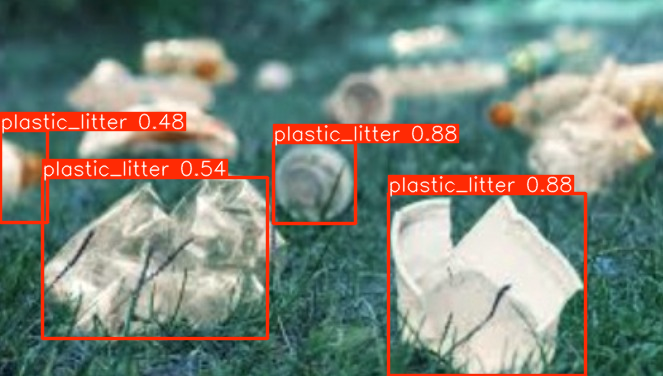

In [5]:
from pathlib import Path
from PIL import Image

best_weights = Path('plastic_project/train/weights/best.pt')

if not best_weights.exists():
    raise FileNotFoundError(f"{best_weights} not found; rerun training or adjust the path.")

test_image = Path('variety_trash.jpeg')
if not test_image.exists():
    raise FileNotFoundError(f"{test_image} not found; place the sample image alongside the notebook.")

infer_model = YOLO(str(best_weights))
results = infer_model(test_image, conf=0.45)  # predict on an image

# print(result)
# Access the results
for result in results:
    im_bgr = result.plot()
    xywh = result.boxes.xywh  # center-x, center-y, width, height
    xywhn = result.boxes.xywhn  # normalized
    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    xyxyn = result.boxes.xyxyn  # normalized
    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    confs = result.boxes.conf  # confidence score of each box

    print(names, confs)

    # Display the test image that was classified
    from IPython.display import display
    display(Image.fromarray(im_bgr))